In [1]:
from langgraph.graph import StateGraph, START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv


In [42]:
class BatsmanState(TypedDict):
    run:int
    balls:int
    fours:int
    sixes:int
    strike_rate:float
    bpb:float
    boundary_percentage:float
    

In [48]:
def calculate_strike_rate(state: BatsmanState) -> dict:
    if state["balls"] == 0:
        return {"strike_rate": 0}
    
    strike_rate = (state["run"] / state["balls"]) * 100
    return {"strike_rate": strike_rate}

In [52]:
def calculate_bpb(state: BatsmanState) -> dict:
    total_boundaries = state["sixes"] + state["fours"]

    if total_boundaries == 0:
        return {"bpb": 0}   # safe fallback

    bpb = state["balls"] / total_boundaries
    return {"bpb": bpb}

In [50]:
def calculate_boundary_percentage(state: BatsmanState) -> dict:
    if state["run"] == 0:
        return {"boundary_percentage": 0}
    
    boundary_runs = (state["fours"] * 4) + (state["sixes"] * 6)
    boundary_percentage = (boundary_runs / state["run"]) * 100
    
    return {"boundary_percentage": boundary_percentage}

In [51]:
def summarize_performance(state: BatsmanState) -> dict:
    summary = f"""
    Runs: {state['run']}
    Balls: {state['balls']}
    Fours: {state['fours']}
    Sixes: {state['sixes']}
    Strike Rate: {state['strike_rate']:.2f}
    BPB: {state['bpb']:.2f}
    Boundary Percentage: {state['boundary_percentage']:.2f}%
    """
    
    return {"summary": summary}

In [53]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate",calculate_strike_rate)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("calculate_boundary_percentage",calculate_boundary_percentage)

graph.add_node("summarize_performance",summarize_performance)

graph.add_edge(START,"calculate_strike_rate")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"calculate_boundary_percentage")
graph.add_edge("calculate_strike_rate","summarize_performance")
graph.add_edge("calculate_bpb","summarize_performance")
graph.add_edge("calculate_boundary_percentage","summarize_performance")
graph.add_edge("summarize_performance",END)

workflow=graph.compile()

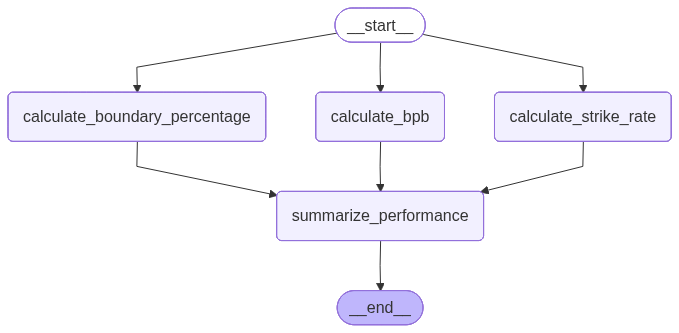

In [54]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [55]:
initial_state= BatsmanState(run=120,balls=80,fours=10,sixes=5)
workflow.invoke(initial_state)



{'run': 120,
 'balls': 80,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 150.0,
 'bpb': 5.333333333333333,
 'boundary_percentage': 58.333333333333336}